In [40]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import models,layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import os


In [34]:
print("📁 Chargement des images...")

# Paramètres simples
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 16

# Chargement direct
train_dataset = tf.keras.utils.image_dataset_from_directory(
    'dataset/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'  # 2 classes = binaire
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    'dataset/validation',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print(f"✅ train: {len(train_dataset.file_paths)} images")
print(f"✅ Validation: {len(validation_dataset.file_paths)} images")
print(f"📊 Classes: {train_dataset.class_names}")

📁 Chargement des images...
Found 320 files belonging to 2 classes.
Found 80 files belonging to 2 classes.
✅ train: 320 images
✅ Validation: 80 images
📊 Classes: ['empty', 'full']


In [35]:
print("⚡ Optimisation...")

# Normalisation simple des pixels
def normaliser(image, label):
    return image / 255.0, label

# Application
train_dataset = train_dataset.map(normaliser)
validation_dataset = validation_dataset.map(normaliser)

print("✅ Images normalisées (0-255 → 0-1)")

⚡ Optimisation...
✅ Images normalisées (0-255 → 0-1)


In [6]:
# === 1. PRÉPARATION DES DONNÉES ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

print(f"Classes détectées : {train_generator.class_indices}")

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.
Classes détectées : {'empty': 0, 'full': 1}


In [41]:
print("🧠 Création du modèle...")

model = models.Sequential([
    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    
    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Bloc 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Classification
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Évite la mémorisation
    layers.Dense(1, activation='sigmoid')  # Sortie: 1=vide, 0=pleine
])

🧠 Création du modèle...


c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
print("🏋️‍♂️ Début de l'entraînement...")

# Callback simple
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'modele_poubelle.h5',
    monitor='val_accuracy',
    save_best_only=True
)

# Entraînement
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[checkpoint],
    verbose=1
)

print("✅ Entraînement terminé!")

🏋️‍♂️ Début de l'entraînement...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5209 - loss: 1.1347

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 455ms/step - accuracy: 0.5813 - loss: 0.8486 - val_accuracy: 0.5375 - val_loss: 0.6929
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7392 - loss: 0.5569

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.7344 - loss: 0.5662 - val_accuracy: 0.7625 - val_loss: 0.5452
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.7595 - loss: 0.4914

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 449ms/step - accuracy: 0.7812 - loss: 0.4742 - val_accuracy: 0.8250 - val_loss: 0.4567
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 385ms/step - accuracy: 0.8625 - loss: 0.3498 - val_accuracy: 0.8250 - val_loss: 0.3467
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step - accuracy: 0.9031 - loss: 0.2509 - val_accuracy: 0.8125 - val_loss: 0.3468
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9381 - loss: 0.1891

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 445ms/step - accuracy: 0.9406 - loss: 0.1914 - val_accuracy: 0.8375 - val_loss: 0.3286
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9214 - loss: 0.1523

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.9281 - loss: 0.1569 - val_accuracy: 0.8500 - val_loss: 0.3655
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9707 - loss: 0.1254

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step - accuracy: 0.9500 - loss: 0.1508 - val_accuracy: 0.8875 - val_loss: 0.3259
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 370ms/step - accuracy: 0.9719 - loss: 0.0911 - val_accuracy: 0.8625 - val_loss: 0.3463
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step - accuracy: 0.9812 - loss: 0.0720 - val_accuracy: 0.8625 - val_loss: 0.3841
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 402ms/step - accuracy: 0.9719 - loss: 0.0836 - val_accuracy: 0.8625 - val_loss: 0.2546
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step - accuracy: 0.9812 - loss: 0.0606 - val_accuracy: 0.8875 - val_loss: 0.4065
Epoch 13/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 385ms/step - accuracy: 0.9844 - loss: 0.0475 - val_accuracy: 0.8875 - val_loss: 0.4743
Epoch 14/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - accuracy: 0.9688 - loss: 0.0855 - val_accuracy: 0.8125 - val_loss: 0.4549
Epoch 15/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 421ms/step - accuracy: 0.9750 - loss: 0.0987 - val_accuracy: 0.862

In [52]:
# ============================
# 5️⃣ SAUVEGARDE DU MODÈLE
# ============================
model.save("trash_classifier.h5")
print("✅ Modèle sauvegardé : modele_poubelle.h5")

✅ Modèle sauvegardé : modele_poubelle.h5


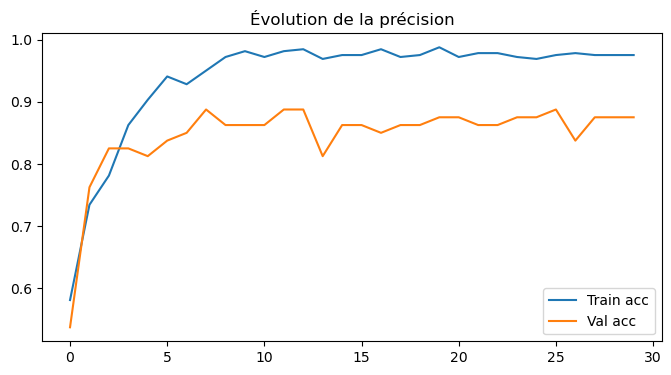

In [53]:

# ============================
# 6️⃣ VISUALISATION DES COURBES
# ============================
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title("Évolution de la précision")
plt.legend()
plt.show()

🧪 TEST DE GÉNÉRALISATION


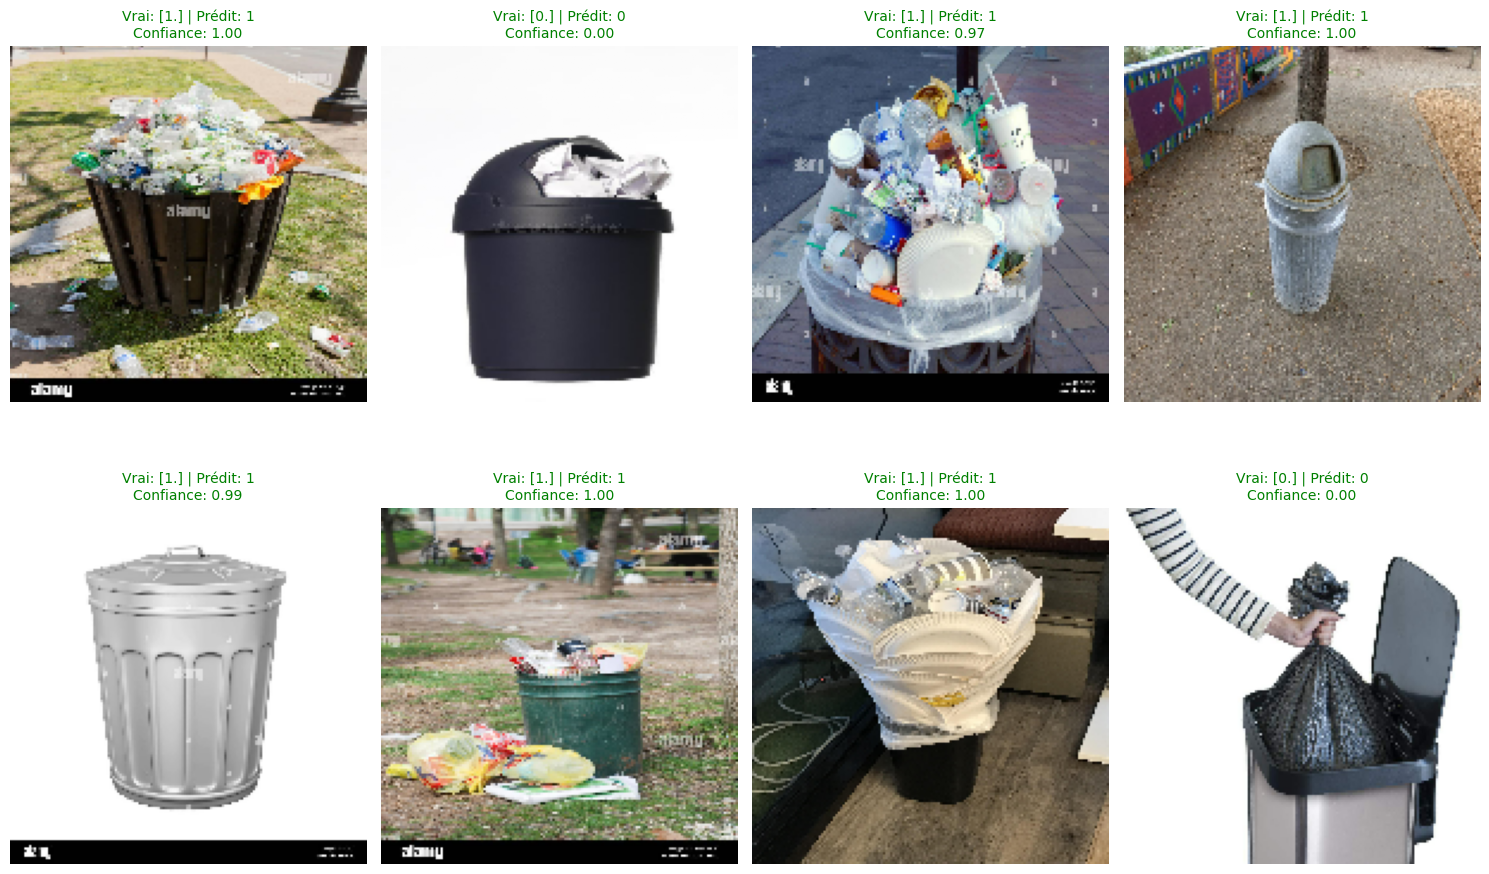

📊 Accuracy sur ce batch: 81.2%


In [47]:
# Cellule - TEST AVEC NOUVELLES IMAGES
print("🧪 TEST DE GÉNÉRALISATION")

def tester_modele():
    """Teste le modèle sur quelques images de validation"""
    
    # Prend un batch de validation
    for images, labels in validation_dataset.take(1):
        predictions = model.predict(images, verbose=0)
        
        # Affiche quelques résultats
        plt.figure(figsize=(15, 10))
        for i in range(min(8, len(images))):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i].numpy())
            
            pred_prob = predictions[i][0]
            true_label = labels[i].numpy()
            pred_label = 1 if pred_prob > 0.5 else 0
            
            # Couleur : vert si correct, rouge si incorrect
            color = 'green' if pred_label == true_label else 'red'
            
            plt.title(f'Vrai: {true_label} | Prédit: {pred_label}\nConfiance: {pred_prob:.2f}', 
                     color=color, fontsize=10)
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Calcul de l'accuracy sur ce batch
        correct = sum(1 for i in range(len(labels)) 
                     if (predictions[i] > 0.5) == labels[i])
        accuracy_batch = correct / len(labels)
        print(f"📊 Accuracy sur ce batch: {accuracy_batch:.1%}")

tester_modele()

In [51]:
# Remplace par ton image test
#image_test = "test_images/.jpg"
#predire_image(image_test)